# In HIN2Vec practice, add meta-path APTP and train, test, visualize again



In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from itertools import product
import random
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.manifold import TSNE

# Random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## HIN model

In [2]:
class HeterogeneousInformationNetwork:

    def __init__(self):
        self.graph = nx.DiGraph()
        self.node_type = {}           # node_id -> type string
        self.edge_type = {}           # (u, v) -> relation string
        self.type_to_nodes = defaultdict(list)  # type -> list of node_ids
        self.node_id_counter = 0
        self.node_label = {}          # node_id -> label (author)
        
    def add_node(self, node_id, node_type, label=None):
        """Add nodes to HIN"""
        self.graph.add_node(node_id)
        self.node_type[node_id] = node_type
        self.type_to_nodes[node_type].append(node_id)
        if label is not None:
            self.node_label[node_id] = label
    
    def add_edge(self, u, v, relation):
        """Add edge to HIN"""
        self.graph.add_edge(u, v)
        self.edge_type[(u, v)] = relation
        # Add reverse edge (undirected HIN)
        self.graph.add_edge(v, u)
        self.edge_type[(v, u)] = relation + '_inv'
    
    def get_neighbors_by_type(self, node, target_type):
        """Take a node and return its neighbors of a specific type"""
        neighbors = []
        for nb in self.graph.neighbors(node):
            if self.node_type[nb] == target_type:
                neighbors.append(nb)
        return neighbors
    
    def get_schema(self):
        """Print out network schema"""
        print("=== Network Schema ===")
        print(f"Node types: {list(self.type_to_nodes.keys())}")
        print(f"Node counts: { {k: len(v) for k, v in self.type_to_nodes.items()} }")
        relation_types = set(self.edge_type.values())
        print(f"Relation types: {[r for r in relation_types if not r.endswith('_inv')]}")
        print(f"Total nodes: {self.graph.number_of_nodes()}")
        print(f"Total edges: {self.graph.number_of_edges() // 2} (bidirectional)")

## Create small DBLP dataset

In [3]:
def create_dblp_hin():
    """
    Create small synthetic DBLP HIN with 4 research groups (40 authors), 8 conferences, 20 terms, and papers connecting them:
    - Group 0: Database (DB)
    - Group 1: Data Mining (DM) 
    - Group 2: Machine Learning (ML)
    - Group 3: Information Retrieval (IR)
    """
    hin = HeterogeneousInformationNetwork()
    
    # --- Create Authors (4 groups, 10 authors each) ---
    research_areas = ['Database', 'DataMining', 'MachineLearning', 'InfoRetrieval']
    authors_per_group = 10
    author_ids = []
    for g, area in enumerate(research_areas):
        for i in range(authors_per_group):
            a_id = f'A{g*authors_per_group + i}'
            hin.add_node(a_id, 'A', label=g)
            author_ids.append((a_id, g))
    
    # --- Create Conferences (8 conferences, 2 for each research area) ---
    conferences = [
        ('C0', 'VLDB'), ('C1', 'SIGMOD'),    # Database
        ('C2', 'KDD'),  ('C3', 'ICDM'),      # Data Mining
        ('C4', 'ICML'), ('C5', 'NeurIPS'),   # Machine Learning
        ('C6', 'SIGIR'), ('C7', 'ECIR'),     # Info Retrieval
    ]
    conf_to_area = {c_id: i//2 for i, (c_id, _) in enumerate(conferences)}
    for c_id, c_name in conferences:
        hin.add_node(c_id, 'C')
    
    # --- Create Terms (20 terms, 5 for each research area) ---
    terms = [
        'query', 'index', 'transaction', 'schema', 'sql',           # DB
        'clustering', 'classification', 'association', 'pattern', 'frequent',  # DM
        'neural', 'gradient', 'optimization', 'regression', 'bayesian',       # ML
        'retrieval', 'ranking', 'relevance', 'document', 'query_expansion',   # IR
    ]
    term_to_area = {f'T{i}': i//5 for i in range(20)}
    for i, t in enumerate(terms):
        hin.add_node(f'T{i}', 'T')
    
    # --- Create Papers and connect them ---
    paper_count = 0
    np.random.seed(SEED)
    
    for g in range(4):  # Each research group
        group_authors = [a_id for a_id, ga in author_ids if ga == g]
        group_confs = [c_id for c_id, _ in conferences if conf_to_area[c_id] == g]
        group_terms = [f'T{i}' for i in range(g*5, (g+1)*5)]
        
        # Each author writes 2-4 papers
        for author in group_authors:
            n_papers = np.random.randint(2, 5)
            for _ in range(n_papers):
                p_id = f'P{paper_count}'
                hin.add_node(p_id, 'P')
                
                # Connect author -> paper
                hin.add_edge(author, p_id, 'writes')
                
                # Add co-author (50% chance)
                if np.random.random() > 0.5:
                    co_author = np.random.choice(group_authors)
                    if co_author != author:
                        hin.add_edge(co_author, p_id, 'writes')
                
                # Occasionally collaborate across research areas (10%)
                if np.random.random() < 0.1:
                    other_group = np.random.choice([x for x in range(4) if x != g])
                    other_authors = [a_id for a_id, ga in author_ids if ga == other_group]
                    cross_author = np.random.choice(other_authors)
                    hin.add_edge(cross_author, p_id, 'writes')
                
                # Connect paper -> conference
                conf = np.random.choice(group_confs)
                hin.add_edge(p_id, conf, 'published_at')
                
                # Connect paper -> terms (2-3 terms)
                n_terms = np.random.randint(2, 4)
                selected_terms = np.random.choice(group_terms, n_terms, replace=False)
                for term in selected_terms:
                    hin.add_edge(p_id, term, 'contains')
                
                paper_count += 1
    
    return hin

# Create HIN
hin = create_dblp_hin()
hin.get_schema()

=== Network Schema ===
Node types: ['A', 'C', 'T', 'P']
Node counts: {'A': 40, 'C': 8, 'T': 20, 'P': 118}
Relation types: ['published_at', 'writes', 'contains']
Total nodes: 186
Total edges: 605 (bidirectional)


## Visualize dataset

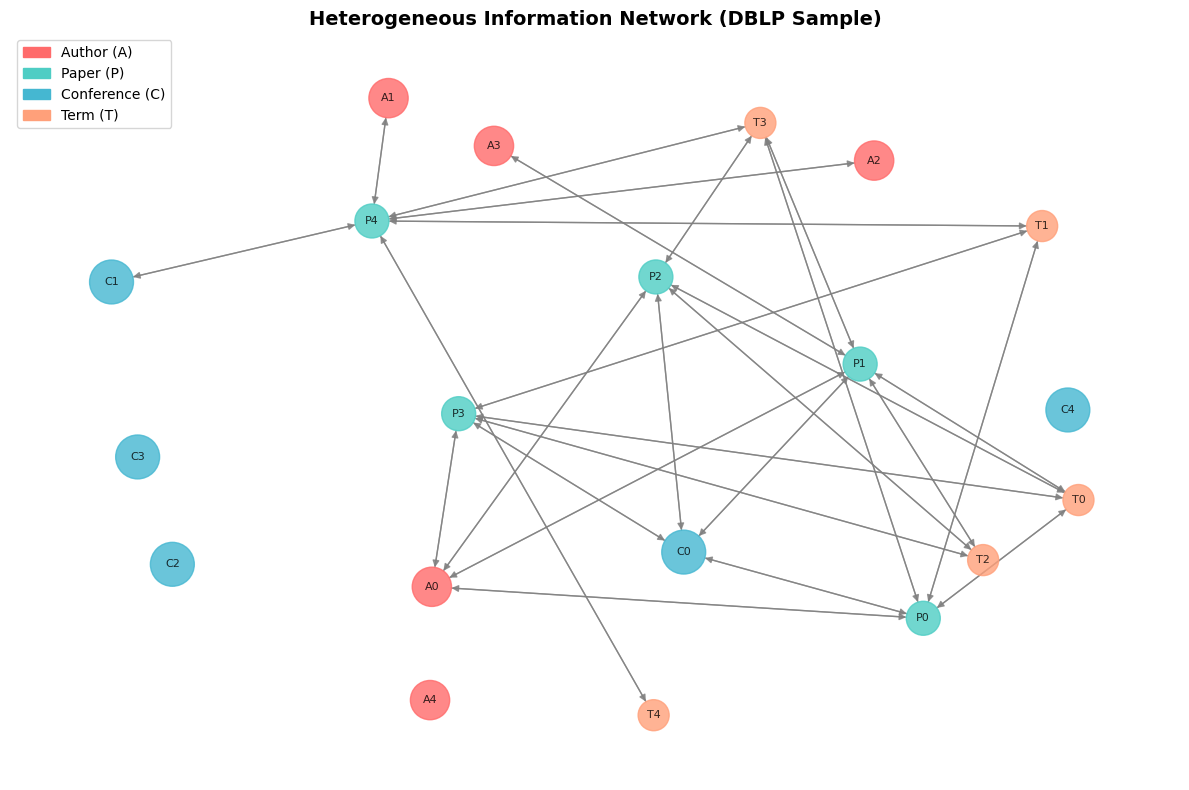

In [4]:
def visualize_hin_sample(hin, n_nodes_per_type=5):
    """Visualize a small portion of the HIN"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Get a sample of nodes to display
    sample_nodes = []
    for ntype, nodes in hin.type_to_nodes.items():
        sample_nodes.extend(nodes[:n_nodes_per_type])
    
    subgraph = hin.graph.subgraph(sample_nodes)
    
    # Color map for node types
    color_map = {'A': '#FF6B6B', 'P': '#4ECDC4', 'C': '#45B7D1', 'T': '#FFA07A'}
    node_colors = [color_map[hin.node_type[n]] for n in subgraph.nodes()]
    
    # Node sizes
    size_map = {'A': 800, 'P': 600, 'C': 1000, 'T': 500}
    node_sizes = [size_map[hin.node_type[n]] for n in subgraph.nodes()]
    
    pos = nx.spring_layout(subgraph, seed=SEED, k=2)
    nx.draw(subgraph, pos, ax=ax,
            node_color=node_colors,
            node_size=node_sizes,
            labels={n: n for n in subgraph.nodes()},
            font_size=8, arrows=True, arrowsize=10,
            edge_color='gray', alpha=0.8)
    
    # Legend
    legend_patches = [
        mpatches.Patch(color='#FF6B6B', label='Author (A)'),
        mpatches.Patch(color='#4ECDC4', label='Paper (P)'),
        mpatches.Patch(color='#45B7D1', label='Conference (C)'),
        mpatches.Patch(color='#FFA07A', label='Term (T)'),
    ]
    ax.legend(handles=legend_patches, loc='upper left', fontsize=10)
    ax.set_title('Heterogeneous Information Network (DBLP Sample)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_hin_sample(hin)

## Define meta-paths

In [5]:
# Define meta-paths
META_PATHS = {
    'APA':   ['A', 'P', 'A'],
    'APCPA': ['A', 'P', 'C', 'P', 'A'],
    'APTPA': ['A', 'P', 'T', 'P', 'A'],
    'APAPA': ['A', 'P', 'A', 'P', 'A'],
    'APTP':  ['A', 'P', 'T', 'P'],
}

print("Meta-paths:")
for name, path in META_PATHS.items():
    arrow_path = ' → '.join(path)
    print(f"  {name}: {arrow_path}")

Meta-paths:
  APA: A → P → A
  APCPA: A → P → C → P → A
  APTPA: A → P → T → P → A
  APAPA: A → P → A → P → A
  APTP: A → P → T → P


## Random walk with meta-path

In [6]:
def metapath_random_walk(hin, start_node, meta_path, walk_length):
    """
    Do random walk along a meta-path.
    
    Args:
        hin: Heterogeneous Information Network
        start_node: Starting node for the walk (must match the first type in meta-path)
        meta_path: List of node types in the meta-path (e.g., ['A', 'P', 'A'])
        walk_length: Maximum number of steps
    
    Returns:
        walk: List of nodes in the random walk
    """
    walk = [start_node]
    current = start_node
    path_len = len(meta_path)
    
    for step in range(walk_length - 1):
        # Determine the next node type based on the meta-path
        current_type_idx = step % (path_len - 1)
        next_type = meta_path[current_type_idx + 1]
        
        # Find neighbors of the correct node type
        candidates = hin.get_neighbors_by_type(current, next_type)
        
        if not candidates:
            break  # No further path available
        
        # Choose a neighbor at random
        next_node = random.choice(candidates)
        walk.append(next_node)
        current = next_node
    
    return walk


def generate_all_walks(hin, meta_path, n_walks=10, walk_length=50):
    """
    Create all random walks along a meta-path.
    
    Args:
        hin: HIN
        meta_path: Meta-path (list of node types)
        n_walks: Number of walks for each starting node
        walk_length: Length of each walk
    
    Returns:
        all_walks: List of all generated walks
    """
    start_type = meta_path[0]
    start_nodes = hin.type_to_nodes[start_type]
    all_walks = []
    
    for node in start_nodes:
        for _ in range(n_walks):
            walk = metapath_random_walk(hin, node, meta_path, walk_length)
            if len(walk) > 1:  # Only keep walks with at least 2 nodes
                all_walks.append(walk)
    
    return all_walks


# random walk
print("=== Example Random Walk following meta-path APA ===")
sample_author = hin.type_to_nodes['A'][0]
walk = metapath_random_walk(hin, sample_author, META_PATHS['APA'], walk_length=10)
print(f"Start: {sample_author} (type: {hin.node_type[sample_author]})")
print(f"Walk: {' -> '.join(walk)}")
print(f"Types: {' -> '.join([hin.node_type[n] for n in walk])}")
print()

print("=== Example Random Walk following meta-path APCPA ===")
walk2 = metapath_random_walk(hin, sample_author, META_PATHS['APCPA'], walk_length=10)
print(f"Walk: {' -> '.join(walk2)}")
print(f"Types: {' -> '.join([hin.node_type[n] for n in walk2])}")

=== Example Random Walk following meta-path APA ===
Start: A0 (type: A)
Walk: A0 -> P11 -> A3 -> P1 -> A3 -> P10 -> A3 -> P10 -> A17 -> P10
Types: A -> P -> A -> P -> A -> P -> A -> P -> A -> P

=== Example Random Walk following meta-path APCPA ===
Walk: A0 -> P11 -> C1 -> P23 -> A7 -> P0 -> C0 -> P3 -> A0 -> P10
Types: A -> P -> C -> P -> A -> P -> C -> P -> A -> P


## Create pairs

In [7]:
def generate_training_pairs(walks, window_size=3):
    """
    Create pairs (node_i, node_j) from the list of walks.
    Two nodes form a positive pair if they are within the window.
    
    Args:
        walks: List of random walks
        window_size: Size of the context window
    
    Returns:
        pairs: List of pairs (node_i, node_j)
    """
    pairs = []
    for walk in walks:
        for i, center in enumerate(walk):
            for j in range(max(0, i - window_size), min(len(walk), i + window_size + 1)):
                if i != j:
                    pairs.append((center, walk[j]))
    return pairs


# Create walks and training pairs for each meta-path
print("Creating random walks...")
all_walks_per_metapath = {}
all_pairs_per_metapath = {}

for mp_name, mp_path in META_PATHS.items():
    walks = generate_all_walks(hin, mp_path, n_walks=5, walk_length=30)
    pairs = generate_training_pairs(walks, window_size=2)
    all_walks_per_metapath[mp_name] = walks
    all_pairs_per_metapath[mp_name] = pairs
    print(f"  {mp_name}: {len(walks)} walks, {len(pairs)} training pairs")

print("\nCompleted creating training data!")

Creating random walks...
  APA: 200 walks, 22800 training pairs
  APCPA: 200 walks, 22800 training pairs
  APTPA: 200 walks, 22800 training pairs
  APAPA: 200 walks, 22800 training pairs
  APTP: 200 walks, 2000 training pairs

Completed creating training data!


## Map node ID

In [8]:
class NodeIndexer:
    """Map node_id (string) to index (integer) for embedding layer"""
    def __init__(self, hin):
        all_nodes = list(hin.graph.nodes())
        self.node2idx = {n: i for i, n in enumerate(all_nodes)}
        self.idx2node = {i: n for i, n in enumerate(all_nodes)}
        self.n_nodes = len(all_nodes)
        
        # Map meta-path name to index
        mp_names = list(META_PATHS.keys())
        self.mp2idx = {mp: i for i, mp in enumerate(mp_names)}
        self.n_metapaths = len(mp_names)
    
    def encode_node(self, node_id):
        return self.node2idx[node_id]
    
    def encode_metapath(self, mp_name):
        return self.mp2idx[mp_name]

indexer = NodeIndexer(hin)
print(f"Total nodes: {indexer.n_nodes}")
print(f"Total meta-paths: {indexer.n_metapaths}")
print(f"Sample: node 'A0' -> index {indexer.encode_node('A0')}")

Total nodes: 186
Total meta-paths: 5
Sample: node 'A0' -> index 0


## HIN2Vec

In [9]:
class HIN2Vec(nn.Module):
    """
    Learning simultaneously:
    - Node embeddings: X ∈ R^(n_nodes × dim)
    - Meta-path embeddings: R ∈ R^(n_metapaths × dim)
    """
    def __init__(self, n_nodes, n_metapaths, embed_dim=64):
        super(HIN2Vec, self).__init__()
        self.embed_dim = embed_dim
        
        # Node embeddings
        self.node_embed = nn.Embedding(n_nodes, embed_dim)
        
        # Meta-path embeddings (with L2 regularization)
        self.mp_embed = nn.Embedding(n_metapaths, embed_dim)
        
        # Output weight vector
        self.output_layer = nn.Linear(embed_dim, 1, bias=False)
        
        # Initialize weights
        nn.init.xavier_uniform_(self.node_embed.weight)
        nn.init.xavier_uniform_(self.mp_embed.weight)
        nn.init.xavier_uniform_(self.output_layer.weight)
    
    def forward(self, node_i, node_j, metapath_idx):
        """
        Args:
            node_i: (batch_size,) - index of source node
            node_j: (batch_size,) - index of target node
            metapath_idx: (batch_size,) - index of meta-path

        Returns:
            prob: (batch_size,) - probability of relation existence
        """
        # Lấy embeddings
        x_i = self.node_embed(node_i)      # (batch, dim)
        x_j = self.node_embed(node_j)      # (batch, dim)
        r_p = self.mp_embed(metapath_idx)  # (batch, dim)
        
        # Hadamard product + tanh
        combined = x_i * x_j * r_p        # element-wise multiply
        combined = torch.tanh(combined)    # activation
        
        # Output
        logit = self.output_layer(combined).squeeze(-1)  # (batch,)
        return logit
    
    def get_node_embeddings(self):
        """Return node embeddings (detach from computation graph)"""
        return self.node_embed.weight.detach().cpu().numpy()
    
    def get_metapath_embeddings(self):
        """Return meta-path embeddings"""
        return self.mp_embed.weight.detach().cpu().numpy()


# Create model
EMBED_DIM = 64
model = HIN2Vec(
    n_nodes=indexer.n_nodes,
    n_metapaths=indexer.n_metapaths,
    embed_dim=EMBED_DIM
)

print("=== Model Architecture: HIN2Vec ===")
print(model)
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}")

=== Model Architecture: HIN2Vec ===
HIN2Vec(
  (node_embed): Embedding(186, 64)
  (mp_embed): Embedding(5, 64)
  (output_layer): Linear(in_features=64, out_features=1, bias=False)
)

Total Parameters: 12,288


## Apply negative sampling

In [10]:
class HIN2VecDataset(Dataset):
    """
    Dataset for HIN2Vec with negative sampling based on node types.
    """
    def __init__(self, hin, indexer, all_pairs_per_metapath, n_negative=5):
        """
        Args:
            hin: HIN object
            indexer: NodeIndexer
            all_pairs_per_metapath: dict {mp_name: [(node_i, node_j), ...]}
            n_negative: Number of negative samples for each positive sample
        """
        self.hin = hin
        self.indexer = indexer
        self.n_negative = n_negative
        
        # Create training samples: (node_i_idx, node_j_idx, mp_idx, label)
        self.samples = []
        
        for mp_name, pairs in all_pairs_per_metapath.items():
            mp_idx = indexer.encode_metapath(mp_name)
            mp_path = META_PATHS[mp_name]
            # Determine target node type based on the last type in the meta-path
            target_type = mp_path[-1]
            target_nodes = hin.type_to_nodes[target_type]
            
            for (ni, nj) in pairs:
                ni_idx = indexer.encode_node(ni)
                nj_idx = indexer.encode_node(nj)
                
                # Positive sample
                self.samples.append((ni_idx, nj_idx, mp_idx, 1.0))
                
                # Negative samples
                for _ in range(n_negative):
                    neg_node = random.choice(target_nodes)
                    while neg_node == nj:  # Avoid sampling the positive node as negative
                        neg_node = random.choice(target_nodes)
                    neg_idx = indexer.encode_node(neg_node)
                    self.samples.append((ni_idx, neg_idx, mp_idx, 0.0))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        ni_idx, nj_idx, mp_idx, label = self.samples[idx]
        return (
            torch.tensor(ni_idx, dtype=torch.long),
            torch.tensor(nj_idx, dtype=torch.long),
            torch.tensor(mp_idx, dtype=torch.long),
            torch.tensor(label, dtype=torch.float)
        )


# Create Dataset and DataLoader
dataset = HIN2VecDataset(hin, indexer, all_pairs_per_metapath, n_negative=5)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

print(f"Dataset size: {len(dataset):,} samples")
print(f"Number of batches: {len(dataloader)}")

# View a batch
batch_ni, batch_nj, batch_mp, batch_label = next(iter(dataloader))
print(f"\nShape of the batch:")
print(f"  node_i: {batch_ni.shape}")
print(f"  node_j: {batch_nj.shape}")
print(f"  metapath: {batch_mp.shape}")
print(f"  label: {batch_label.shape}")
print(f"  Positive ratio: {batch_label.mean():.3f} (Ideal: {1/(1+5):.3f})")

Dataset size: 559,200 samples
Number of batches: 2185

Shape of the batch:
  node_i: torch.Size([256])
  node_j: torch.Size([256])
  metapath: torch.Size([256])
  label: torch.Size([256])
  Positive ratio: 0.164 (Ideal: 0.167)


## Train

In [16]:
def train_hin2vec(model, dataloader, n_epochs=30, lr=0.01, weight_decay=1e-4, device=None):
    """
    Train HIN2Vec.

    Loss function: Binary Cross Entropy (with negative sampling)
    $L = -\sum [y \log \hat{y} + (1-y) \log(1-\hat{y})]$

    Args:
        model: HIN2Vec model
        dataloader: Training data loader
        n_epochs: Number of epochs
        lr: Learning rate
        weight_decay: Weight decay for regularization

    """
    # Auto-detect device if not specified
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"Training on device: {device}")

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    history = {'loss': [], 'epoch': []}

    model.train()
    for epoch in range(n_epochs):
        total_loss = 0.0
        n_batches = 0

        for batch_ni, batch_nj, batch_mp, batch_label in dataloader:
            # Move batch to device
            batch_ni = batch_ni.to(device)
            batch_nj = batch_nj.to(device)
            batch_mp = batch_mp.to(device)
            batch_label = batch_label.to(device)

            optimizer.zero_grad()

            # Forward pass
            logits = model(batch_ni, batch_nj, batch_mp)

            # Calculate loss
            loss = criterion(logits, batch_label)

            # Backward pass
            loss.backward()

            # Gradient clipping (to prevent exploding gradients)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            # Regularize meta-path embeddings (L2 normalize)
            with torch.no_grad():
                mp_norm = model.mp_embed.weight.norm(dim=1, keepdim=True)
                model.mp_embed.weight.data = model.mp_embed.weight.data / (mp_norm + 1e-8)

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / n_batches
        history['loss'].append(avg_loss)
        history['epoch'].append(epoch + 1)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1:3d}/{n_epochs}] | Loss: {avg_loss:.4f}")

    return history


print("Starting HIN2Vec training...\n")
history = train_hin2vec(model, dataloader, n_epochs=30, lr=0.01)
print("\n✅ Training completed!")

<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_6069/1697831125.py:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  $L = -\sum [y \log \hat{y} + (1-y) \log(1-\hat{y})]$


Starting HIN2Vec training...

Training on device: cuda
Epoch [  5/30] | Loss: 0.1918
Epoch [ 10/30] | Loss: 0.1906
Epoch [ 15/30] | Loss: 0.1897
Epoch [ 20/30] | Loss: 0.1894
Epoch [ 25/30] | Loss: 0.1894
Epoch [ 30/30] | Loss: 0.1896

✅ Training completed!


## Loss Visualization

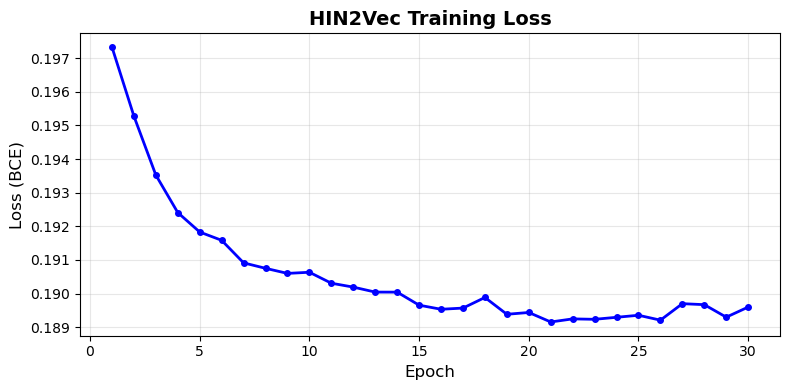

Final loss: 0.1896


In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history['epoch'], history['loss'], 'b-o', markersize=4, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (BCE)', fontsize=12)
plt.title('HIN2Vec Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Final loss: {history['loss'][-1]:.4f}")

## Evaluation

In [18]:
def evaluate_node_classification(model, hin, indexer):
    """
    Evaluate node embeddings on Author classification task (predict research area).
    """
    model.eval()
    
    # Take node embeddings
    all_embeddings = model.get_node_embeddings()
    
    # Prepare features and labels for Authors
    X, y = [], []
    for author in hin.type_to_nodes['A']:
        if author in hin.node_label:
            idx = indexer.encode_node(author)
            X.append(all_embeddings[idx])
            y.append(hin.node_label[author])
    
    X = np.array(X)
    y = np.array(y)
    
    print(f"Evaluation data: {len(X)} authors, {len(set(y))} classes")
    
    # Train/test split
    results = {}
    for train_ratio in [0.3, 0.5, 0.7]:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=train_ratio, random_state=SEED, stratify=y
        )
        
        # Logistic Regression classifier
        clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        macro_f1 = f1_score(y_test, y_pred, average='macro')
        micro_f1 = f1_score(y_test, y_pred, average='micro')
        acc = accuracy_score(y_test, y_pred)
        
        results[train_ratio] = {'macro_f1': macro_f1, 'micro_f1': micro_f1, 'acc': acc}
        print(f"  Train {int(train_ratio*100)}% | Acc: {acc:.4f} | Macro-F1: {macro_f1:.4f} | Micro-F1: {micro_f1:.4f}")
    
    return X, y, results


print("=== Node Classification (Author Research Area) ===")
embeddings_2d, labels, eval_results = evaluate_node_classification(model, hin, indexer)

=== Node Classification (Author Research Area) ===
Evaluation data: 40 authors, 4 classes
  Train 30% | Acc: 0.7143 | Macro-F1: 0.6717 | Micro-F1: 0.7143
  Train 50% | Acc: 0.9000 | Macro-F1: 0.8995 | Micro-F1: 0.9000
  Train 70% | Acc: 0.9167 | Macro-F1: 0.9143 | Micro-F1: 0.9167


## Visualize meta-path embeddings

=== Meta-path Embeddings ===
Shape: (5, 64)



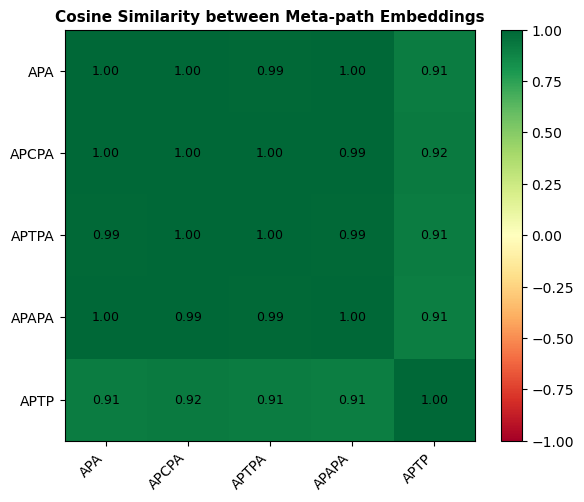

In [19]:
mp_embeddings = model.get_metapath_embeddings()
mp_names = list(META_PATHS.keys())

print("=== Meta-path Embeddings ===")
print(f"Shape: {mp_embeddings.shape}")
print()

# Calculate cosine similarity between meta-paths
from sklearn.metrics.pairwise import cosine_similarity
mp_sim = cosine_similarity(mp_embeddings)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mp_sim, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(mp_names)))
ax.set_yticks(range(len(mp_names)))
ax.set_xticklabels(mp_names, rotation=45, ha='right')
ax.set_yticklabels(mp_names)
plt.colorbar(im, ax=ax)
ax.set_title('Cosine Similarity between Meta-path Embeddings', fontsize=11, fontweight='bold')

for i in range(len(mp_names)):
    for j in range(len(mp_names)):
        ax.text(j, i, f'{mp_sim[i,j]:.2f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()